In [1]:
import yfinance as yf
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [31]:
ticker = yf.Ticker('NVDA')
df = ticker.history(start = '2020-01-01',end = '2024-12-31') 
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(1257, 7)
                               Open      High       Low     Close     Volume  \
Date                                                                           
2020-01-02 00:00:00-05:00  5.941885  5.970754  5.891364  5.970754  237536000   
2020-01-03 00:00:00-05:00  5.851046  5.918989  5.826158  5.875187  205384000   
2020-01-06 00:00:00-05:00  5.781858  5.905051  5.755726  5.899825  262636000   
2020-01-07 00:00:00-05:00  5.928197  6.017045  5.883151  5.971252  314856000   
2020-01-08 00:00:00-05:00  5.967022  6.023765  5.926953  5.982452  277108000   

                           Dividends  Stock Splits  
Date                                                
2020-01-02 00:00:00-05:00        0.0           0.0  
2020-01-03 00:00:00-05:00        0.0           0.0  
2020-01-06 00:00:00-05:00        0.0           0.0  
2020-01-07 00:00:00-05:00        0.0           0.0  
2020-01-08 00:00:00-05:00        0.0           0.0  
Open            float64
High            float64
Low       

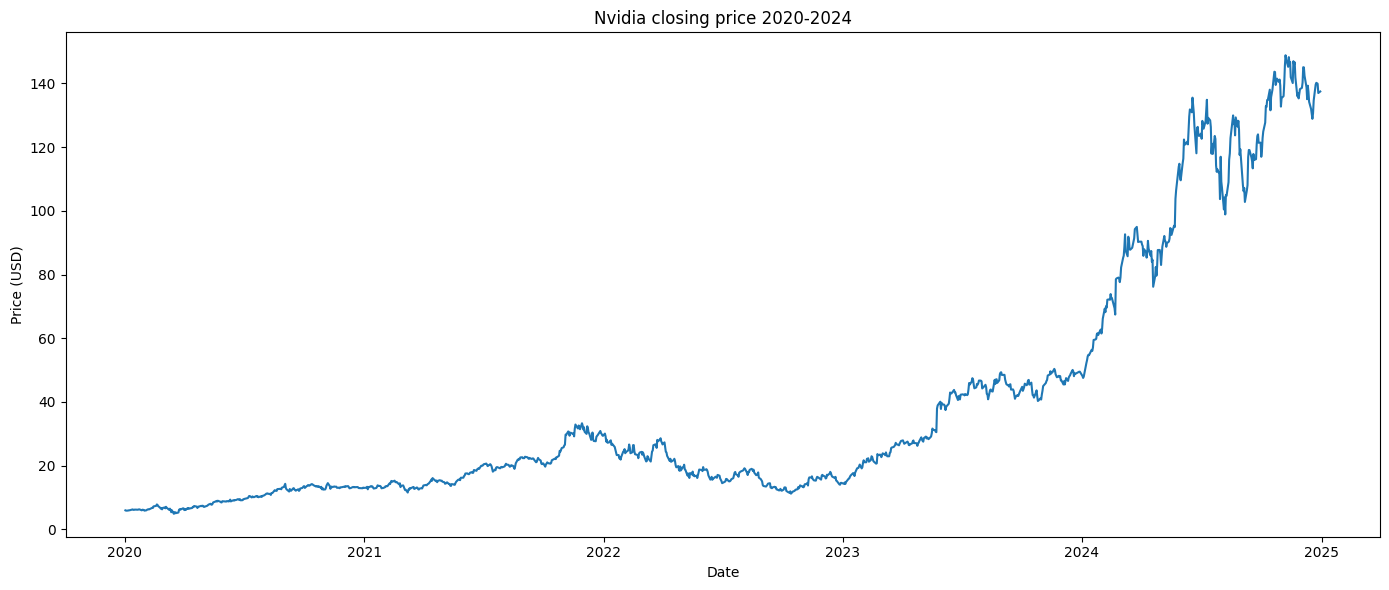

In [32]:
plt.figure(figsize = (14,6))
plt.plot(df.index,df['Close'])
plt.title('Nvidia closing price 2020-2024')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

count    1256.000000
mean        0.003071
std         0.033946
min        -0.184521
25%        -0.015979
50%         0.003297
75%         0.022333
max         0.243696
Name: Daily_Return, dtype: float64


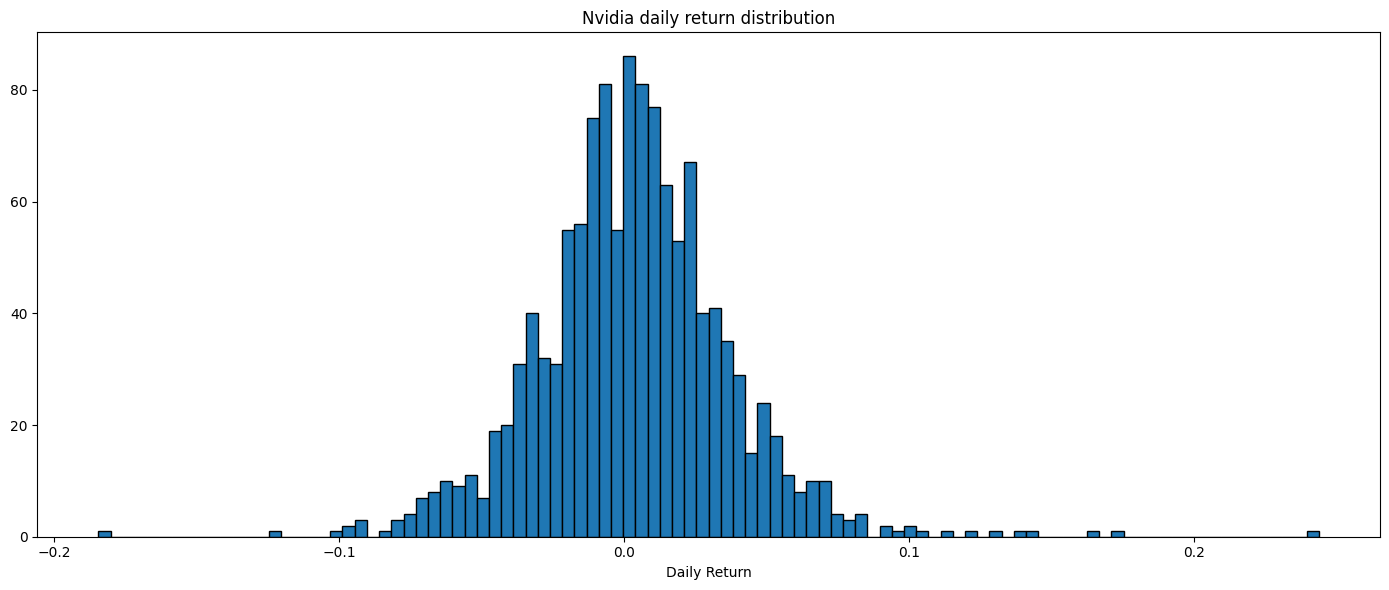

In [33]:
df['Daily_Return'] = df['Close'].pct_change()

print(df['Daily_Return'].describe())
plt.figure(figsize = (14,6))
plt.hist(df['Daily_Return'].dropna(),edgecolor = 'black',bins = 100)
plt.xlabel('Daily Return')
plt.title('Nvidia daily return distribution')
plt.tight_layout()
plt.show()

In [52]:
df['Baseline_pred'] = df['Close'].shift(1)

from sklearn.metrics import mean_absolute_percentage_error

split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:].dropna()

baseline_mape = mean_absolute_percentage_error(test_df['Close'],test_df['Baseline_pred']) * 100
print(f'baseline mape is {baseline_mape:.2f}%')

baseline mape is 2.46%
